In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
df = pd.read_csv(r"C:\Users\dell\OneDrive\Documents\ml_excersise\diabetes_risk_prediction_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


In [123]:
df.shape

(50000, 41)

In [124]:
df.isnull().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

In [125]:
y = df['Diabetes_Risk']
y.head()

0    Moderate
1        High
2        High
3        High
4        High
Name: Diabetes_Risk, dtype: str

In [126]:
df = df.drop(columns=["Patient_ID","AI_Health_Recommendation"])
df.head(1)

,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,Doctor_Consultation_Needed,Diabetes_Risk
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,Yes,Yes,No,Good,Retired,Rural,4.4,60,Yes,Moderate


In [127]:
df['Country'].unique()

<ArrowStringArray>
[        'Mexico',   'Saudi Arabia',      'Argentina',  'United States',
      'Australia',     'Bangladesh',        'Germany',       'Malaysia',
         'France',      'Indonesia',         'Turkey',   'South Africa',
        'Nigeria',         'Canada',    'South Korea',          'Spain',
       'Pakistan',          'India',         'Russia',          'China',
          'Italy',          'Egypt', 'United Kingdom',         'Brazil',
          'Japan']
Length: 25, dtype: str

In [128]:
df['Age'] = df['Age'].fillna(54.0)
df['Sleep_Hours'] = df['Sleep_Hours'].fillna(6.5)
df['Height_cm'] = df['Height_cm'].fillna(170.0)
df['Weight_kg']= df['Weight_kg'].fillna(87.3)
df['Blood_Glucose']= df['Blood_Glucose'].fillna(159.9)
df['HbA1c'] = df['HbA1c'].fillna(8.5)
df['Total_Cholesterol'] = df['Total_Cholesterol'].fillna(220.4)
df['HDL'] = df['HDL'].fillna(57.3)
df['LDL'] = df['LDL'].fillna(135.1)
df['Triglycerides'] = df['Triglycerides'].fillna(229.5)
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].fillna('Low')
df['Medication_Adherence'] = df['Medication_Adherence'].fillna('Good')
df['Exercise_Hours_Per_Week'] = df['Exercise_Hours_Per_Week'].fillna(5.0)
df['Daily_Walking_Minutes'] = df['Daily_Walking_Minutes'].fillna(89.8)

In [129]:
risk_precentials = df['Diabetes_Risk'].value_counts(normalize=True)*100
risk_precentials

Diabetes_Risk
High        73.186
Moderate    25.874
Low          0.940
Name: proportion, dtype: float64

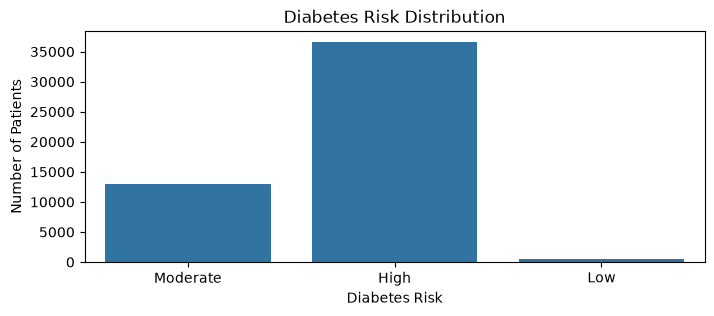

In [130]:
plt.figure(figsize=(8,3))
sns.countplot(data=df,x = 'Diabetes_Risk')
plt.title("Diabetes Risk Distribution")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Patients")

plt.show()

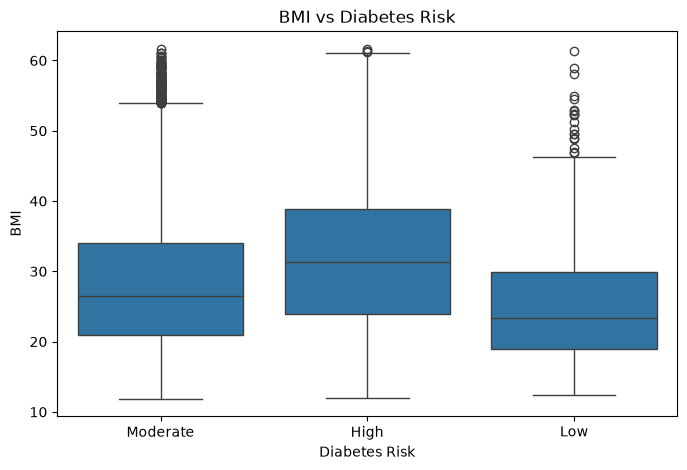

In [131]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="BMI")

plt.title("BMI vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("BMI")

plt.show()

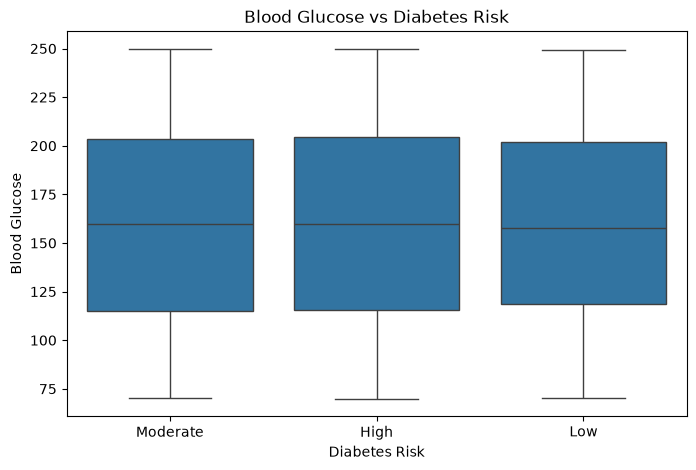

In [132]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="Blood_Glucose")

plt.title("Blood Glucose vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Blood Glucose")

plt.show()

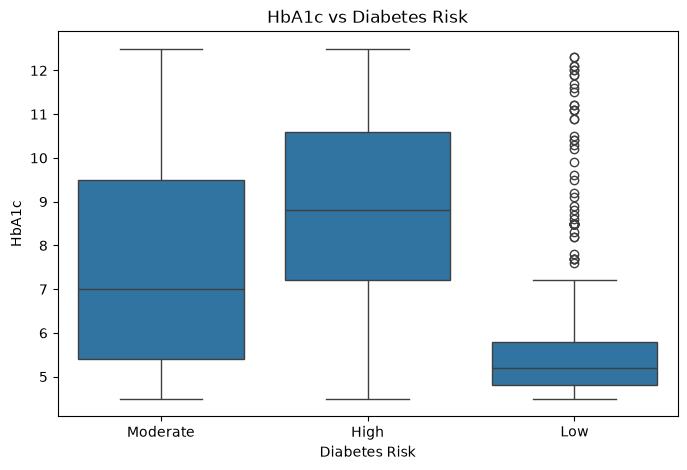

In [133]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="HbA1c")

plt.title("HbA1c vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("HbA1c")

plt.show()

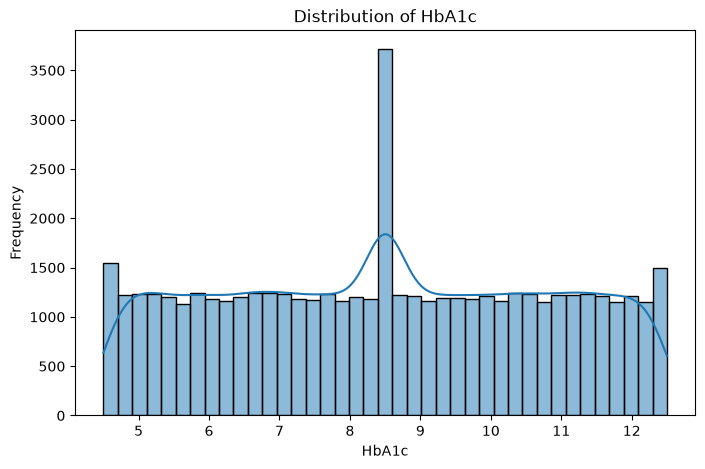

In [134]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="HbA1c", kde=True)

plt.title("Distribution of HbA1c")
plt.xlabel("HbA1c")
plt.ylabel("Frequency")

plt.show()

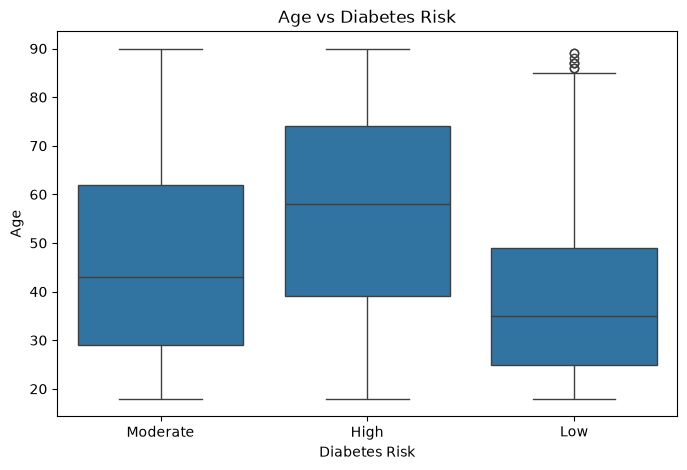

In [135]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="Age")

plt.title("Age vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Age")

plt.show()

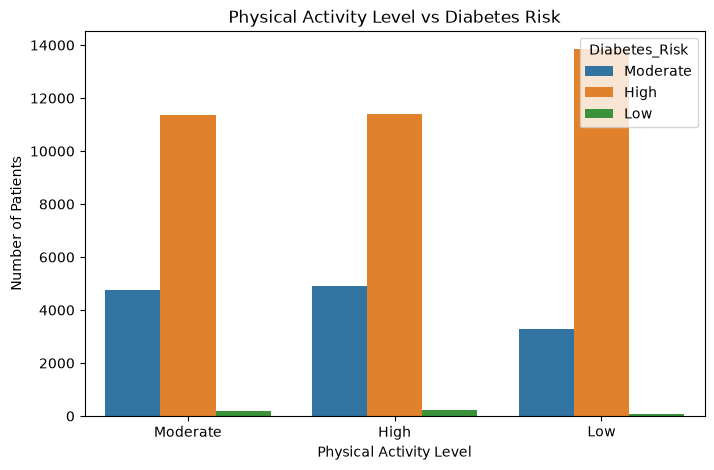

In [136]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Physical_Activity_Level", hue="Diabetes_Risk")

plt.title("Physical Activity Level vs Diabetes Risk")
plt.xlabel("Physical Activity Level")
plt.ylabel("Number of Patients")

plt.show()

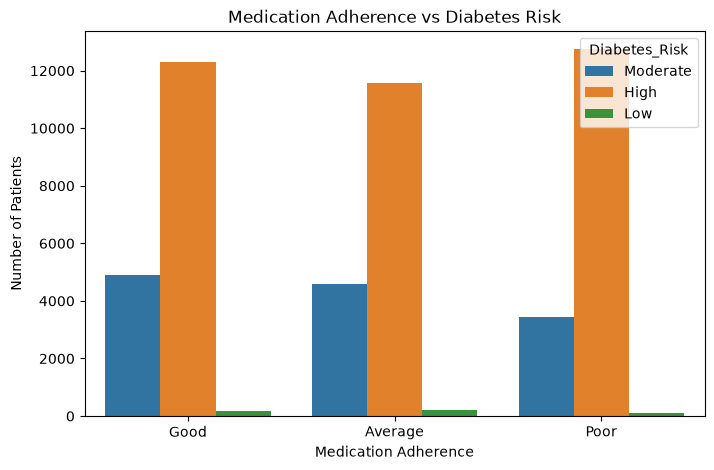

In [137]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Medication_Adherence", hue="Diabetes_Risk")

plt.title("Medication Adherence vs Diabetes Risk")
plt.xlabel("Medication Adherence")
plt.ylabel("Number of Patients")

plt.show()

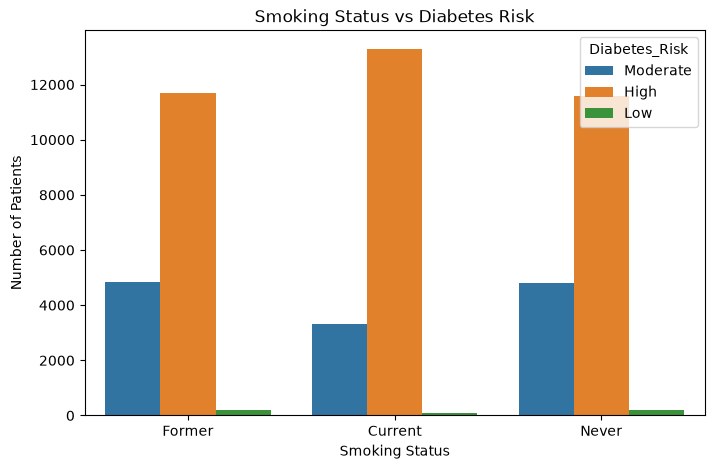

In [138]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Smoking_Status", hue="Diabetes_Risk")

plt.title("Smoking Status vs Diabetes Risk")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")

plt.show()

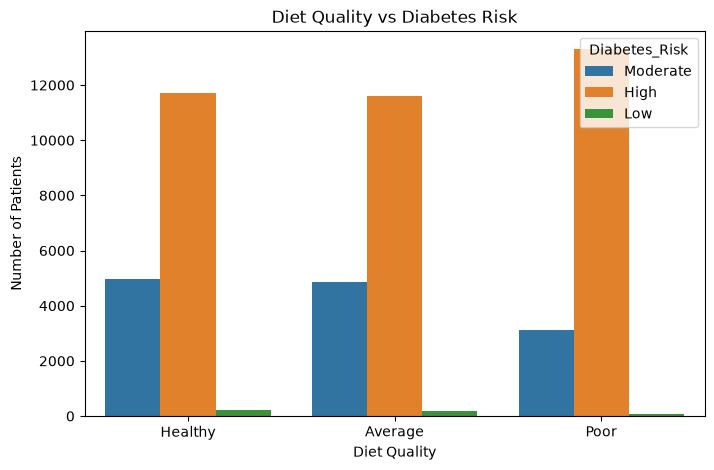

In [139]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Diet_Quality", hue="Diabetes_Risk")

plt.title("Diet Quality vs Diabetes Risk")
plt.xlabel("Diet Quality")
plt.ylabel("Number of Patients")

plt.show()

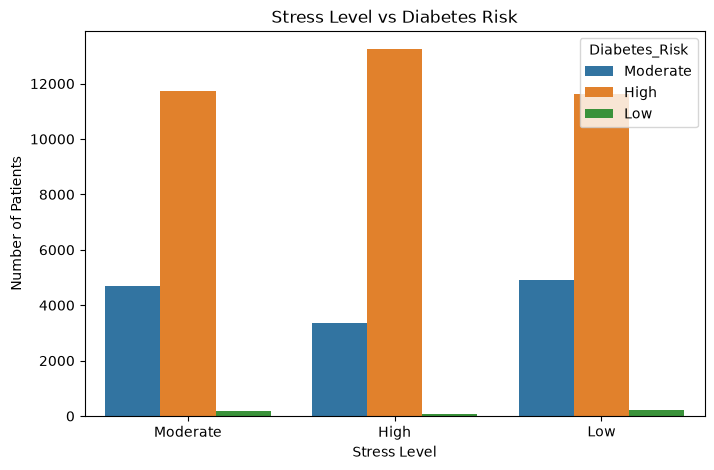

In [140]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Stress_Level", hue="Diabetes_Risk")

plt.title("Stress Level vs Diabetes Risk")
plt.xlabel("Stress Level")
plt.ylabel("Number of Patients")

plt.show()

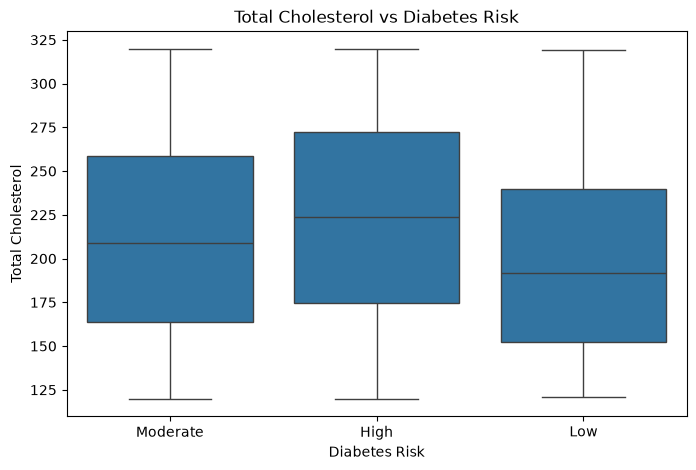

In [141]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="Total_Cholesterol")

plt.title("Total Cholesterol vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Total Cholesterol")

plt.show()

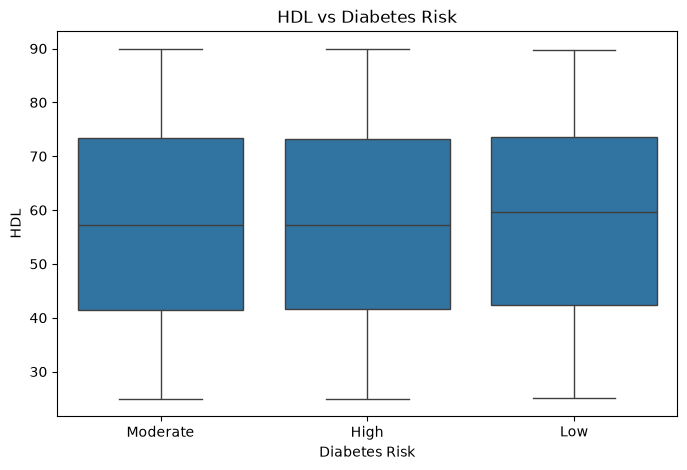

In [142]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="HDL")

plt.title("HDL vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("HDL")

plt.show()

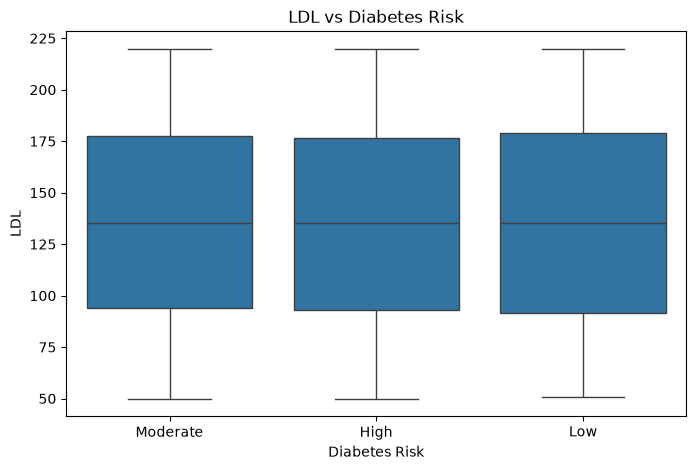

In [143]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="LDL")

plt.title("LDL vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("LDL")

plt.show()

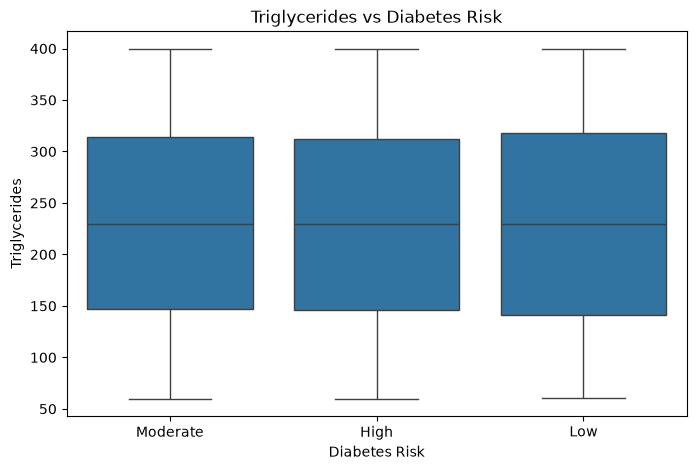

In [144]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="Triglycerides")

plt.title("Triglycerides vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Triglycerides")

plt.show()

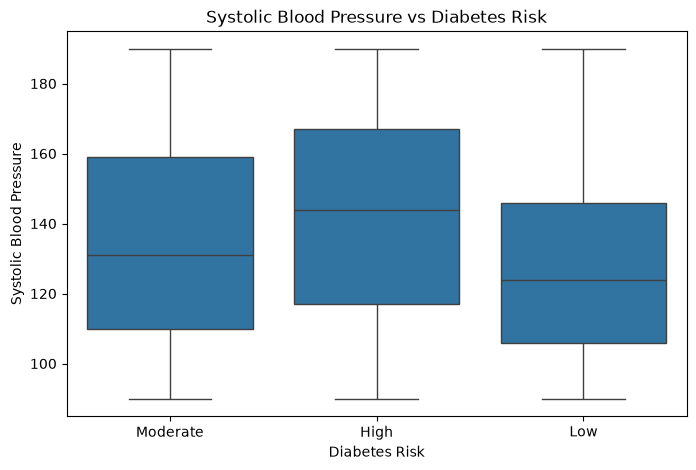

In [145]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Diabetes_Risk", y="Blood_Pressure_Systolic")

plt.title("Systolic Blood Pressure vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Systolic Blood Pressure")

plt.show()

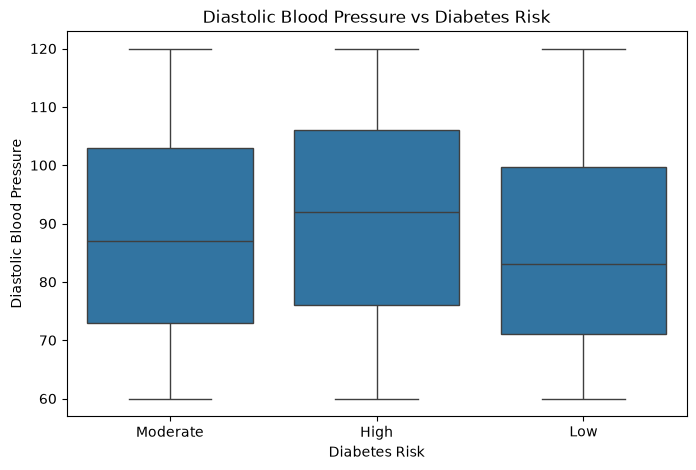

In [146]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_Risk",
    y="Blood_Pressure_Diastolic"
)

plt.title("Diastolic Blood Pressure vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Diastolic Blood Pressure")

plt.show()

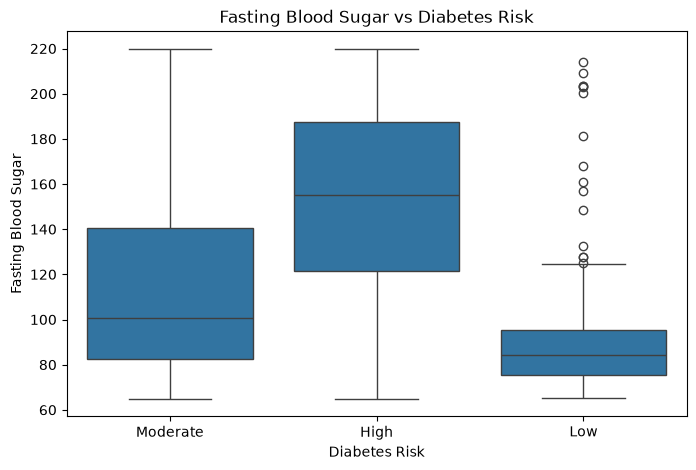

In [147]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_Risk",
    y="Fasting_Blood_Sugar"
)

plt.title("Fasting Blood Sugar vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Fasting Blood Sugar")

plt.show()

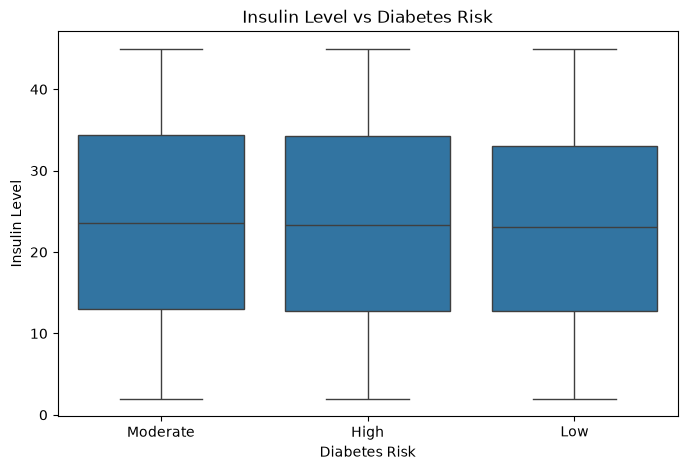

In [148]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_Risk",
    y="Insulin_Level"
)

plt.title("Insulin Level vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Insulin Level")

plt.show()

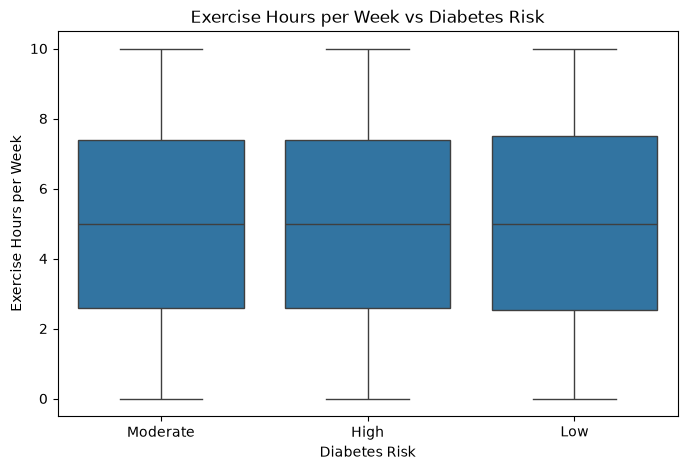

In [149]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_Risk",
    y="Exercise_Hours_Per_Week"
)

plt.title("Exercise Hours per Week vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Exercise Hours per Week")

plt.show()

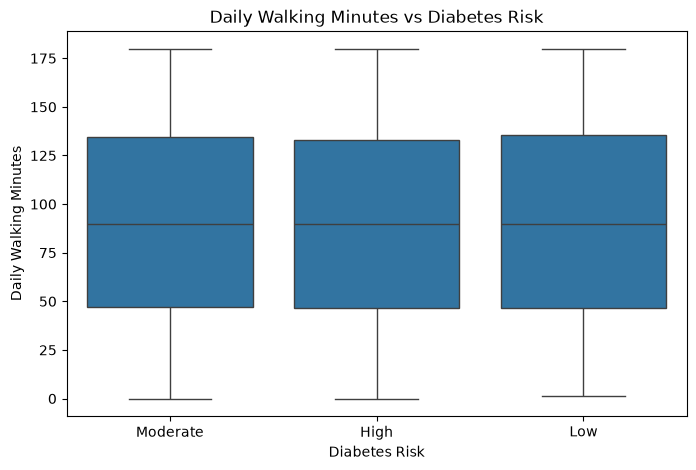

In [150]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_Risk",
    y="Daily_Walking_Minutes"
)

plt.title("Daily Walking Minutes vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Daily Walking Minutes")

plt.show()

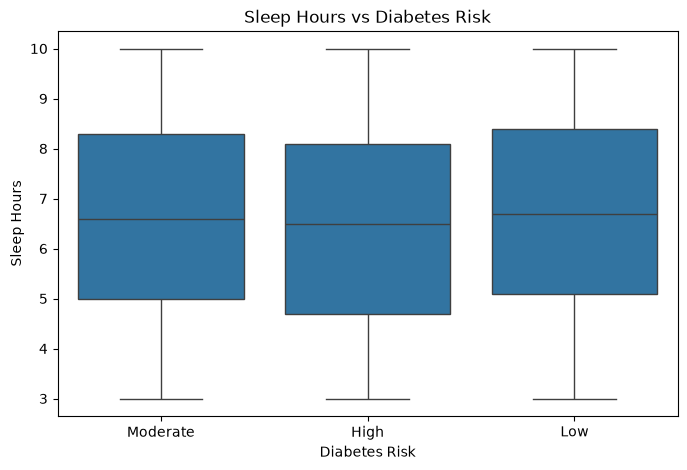

In [151]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_Risk",
    y="Sleep_Hours"
)

plt.title("Sleep Hours vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Sleep Hours")

plt.show()

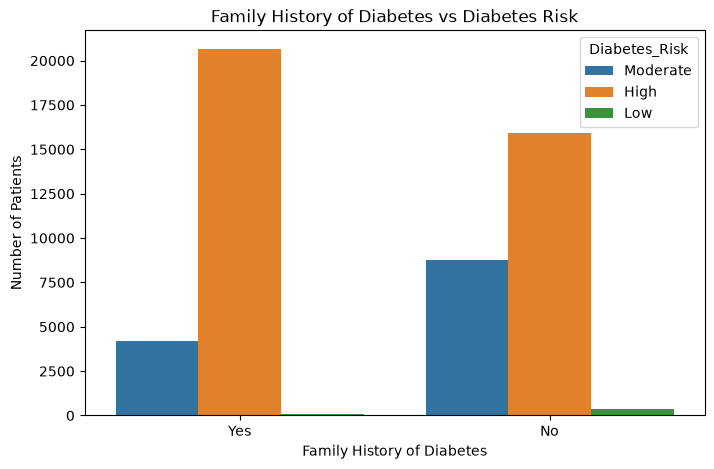

In [153]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Family_History_Diabetes",
    hue="Diabetes_Risk"
)

plt.title("Family History of Diabetes vs Diabetes Risk")
plt.xlabel("Family History of Diabetes")
plt.ylabel("Number of Patients")
plt.show()

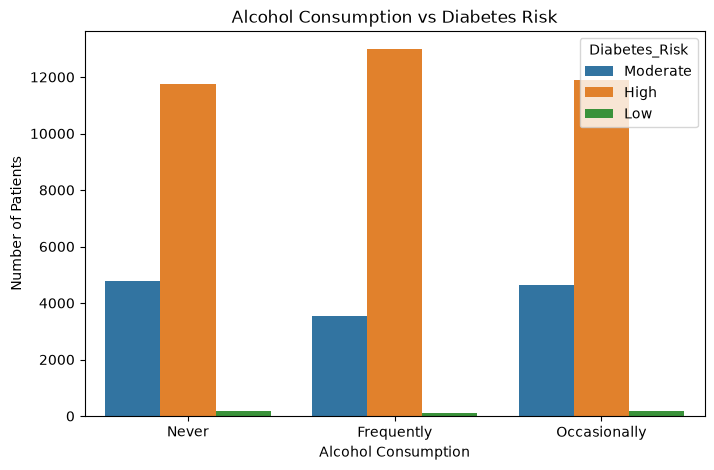

In [154]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Alcohol_Consumption",
    hue="Diabetes_Risk"
)

plt.title("Alcohol Consumption vs Diabetes Risk")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of Patients")

plt.show()

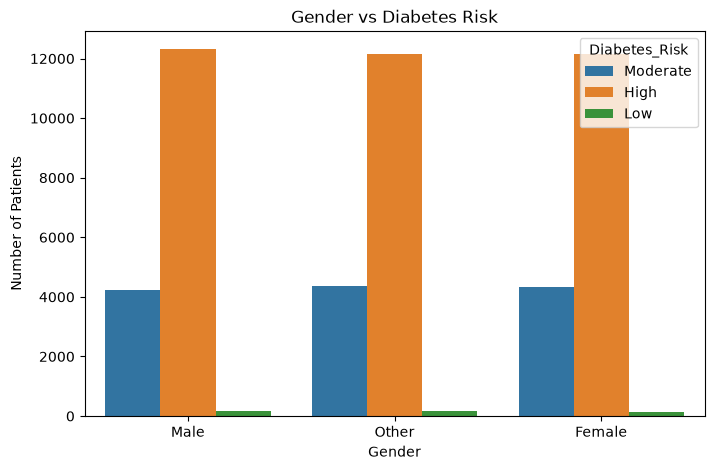

In [155]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Diabetes_Risk"
)

plt.title("Gender vs Diabetes Risk")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

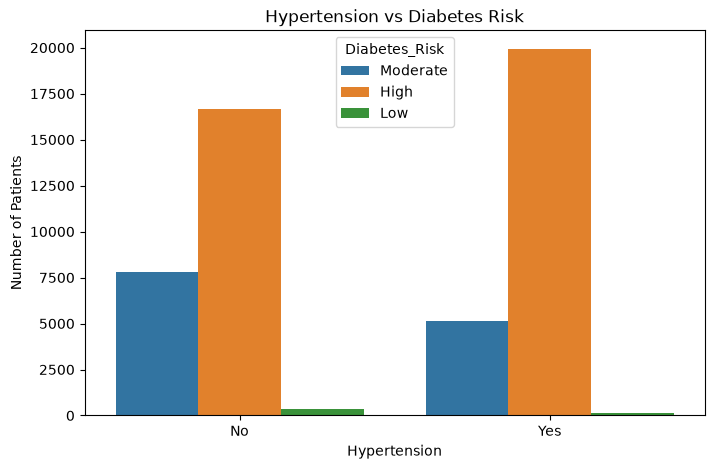

In [157]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Hypertension",
    hue="Diabetes_Risk"
)

plt.title("Hypertension vs Diabetes Risk")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")
plt.show()

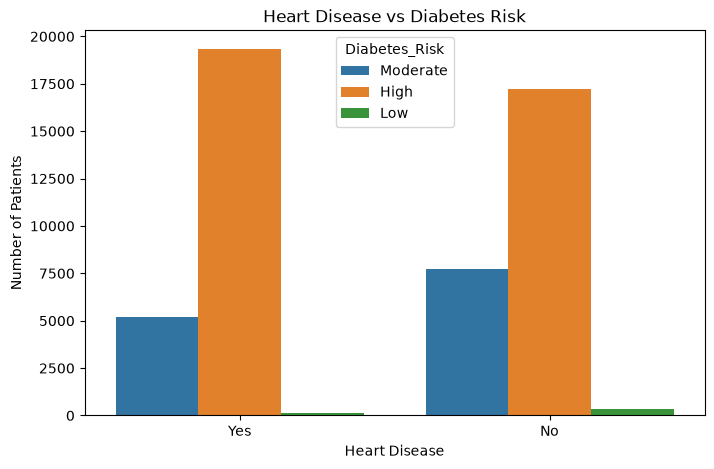

In [159]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Heart_Disease",
    hue="Diabetes_Risk"
)

plt.title("Heart Disease vs Diabetes Risk")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

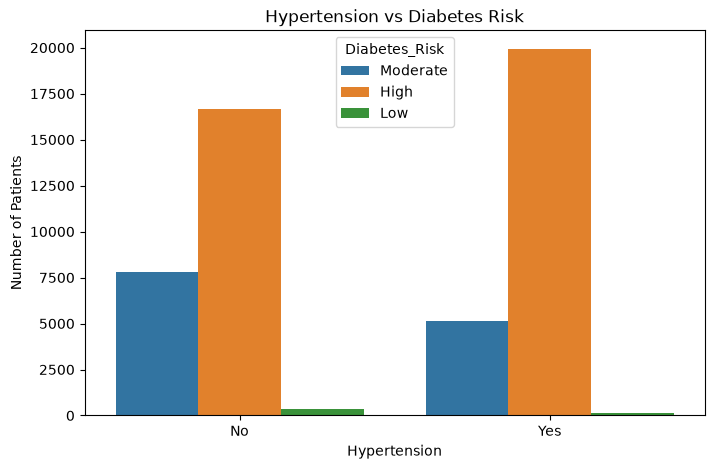

In [162]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Hypertension",
    hue="Diabetes_Risk"
)

plt.title("Hypertension vs Diabetes Risk")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")

plt.show()

In [161]:
print(df.columns.tolist())

['Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score', 'Doctor_Consultation_Needed', 'Diabetes_Risk']


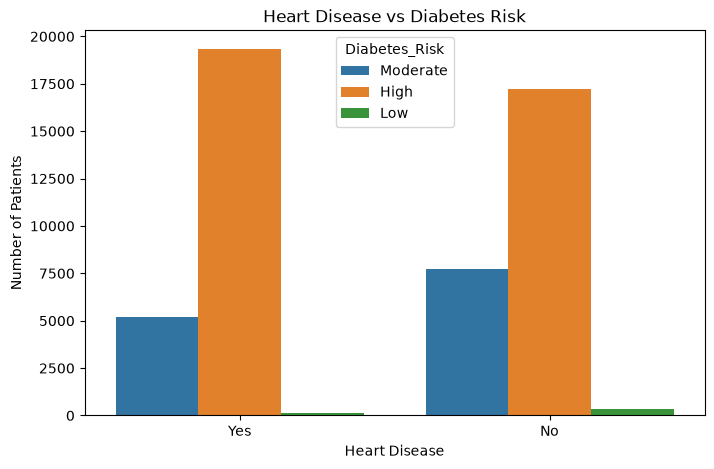

In [163]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Heart_Disease",
    hue="Diabetes_Risk"
)

plt.title("Heart Disease vs Diabetes Risk")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

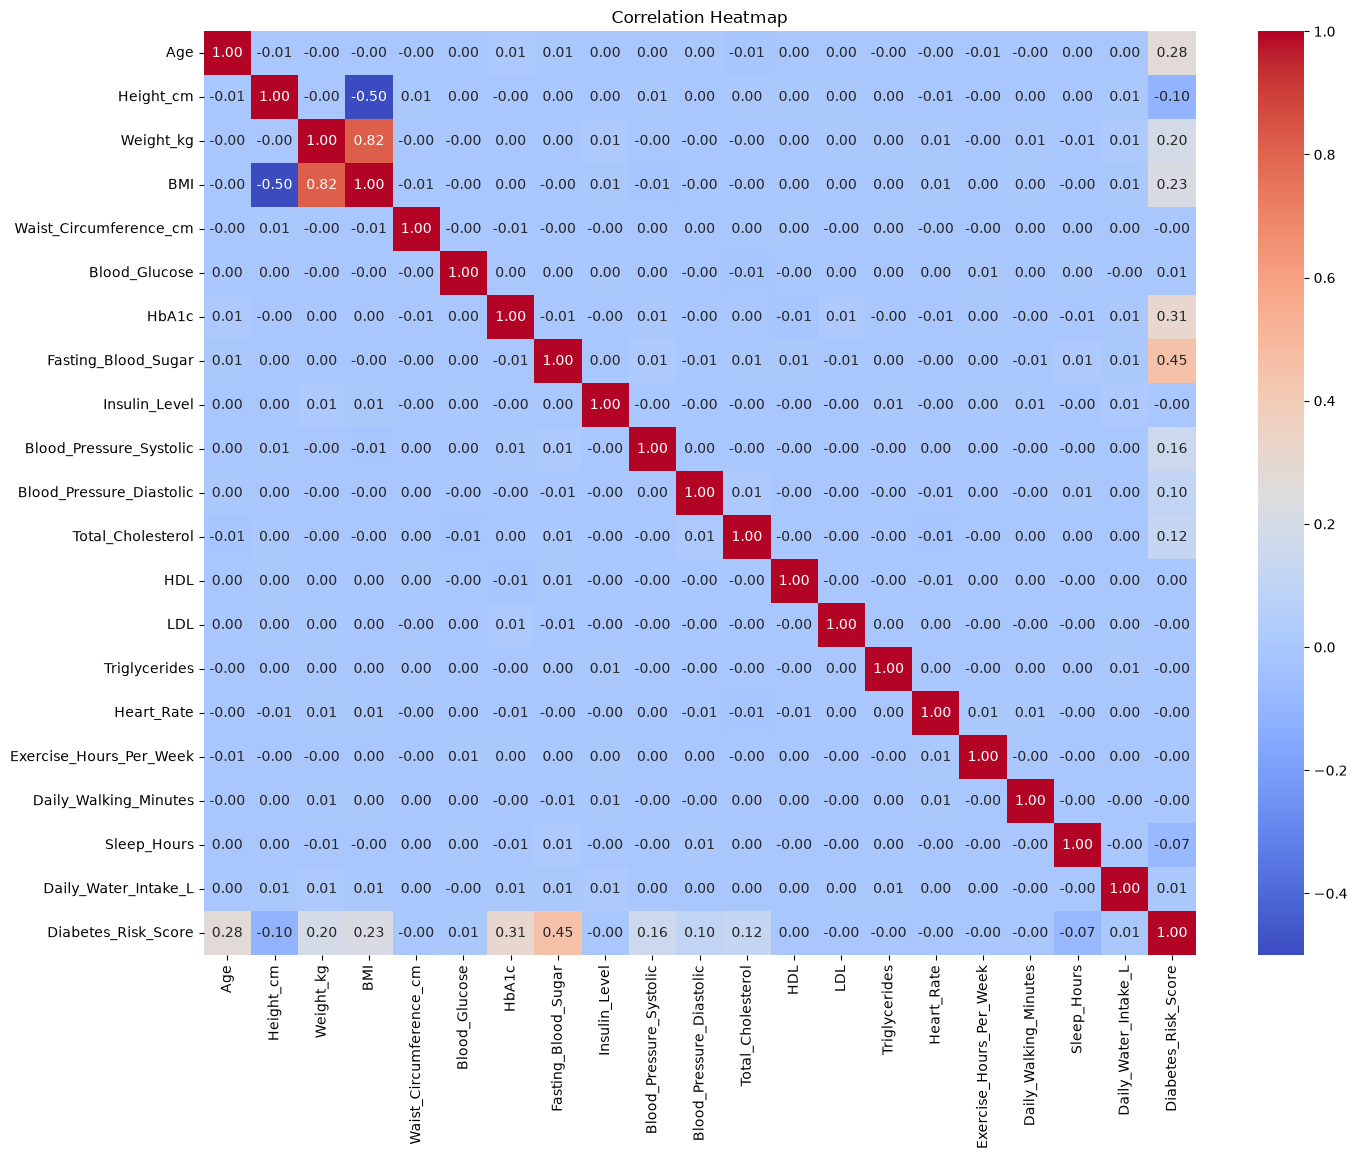

In [164]:
plt.figure(figsize=(16, 12))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [166]:
risk_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

df["Diabetes_Risk_Num"] = df["Diabetes_Risk"].map(risk_map)
risk_corr = df.select_dtypes(include="number").corr()["Diabetes_Risk_Num"].sort_values(ascending=False)

print(risk_corr)

Diabetes_Risk_Num           1.000000
Diabetes_Risk_Score         0.795578
Fasting_Blood_Sugar         0.379986
HbA1c                       0.269206
Age                         0.209807
BMI                         0.161372
Weight_kg                   0.142848
Blood_Pressure_Systolic     0.119854
Total_Cholesterol           0.092625
Blood_Pressure_Diastolic    0.072522
Daily_Water_Intake_L        0.011354
Blood_Glucose               0.005362
HDL                         0.000708
Triglycerides               0.000422
Heart_Rate                  0.000196
Exercise_Hours_Per_Week     0.000148
LDL                        -0.003724
Daily_Walking_Minutes      -0.004185
Insulin_Level              -0.004483
Waist_Circumference_cm     -0.004511
Sleep_Hours                -0.049014
Height_cm                  -0.074597
Name: Diabetes_Risk_Num, dtype: float64


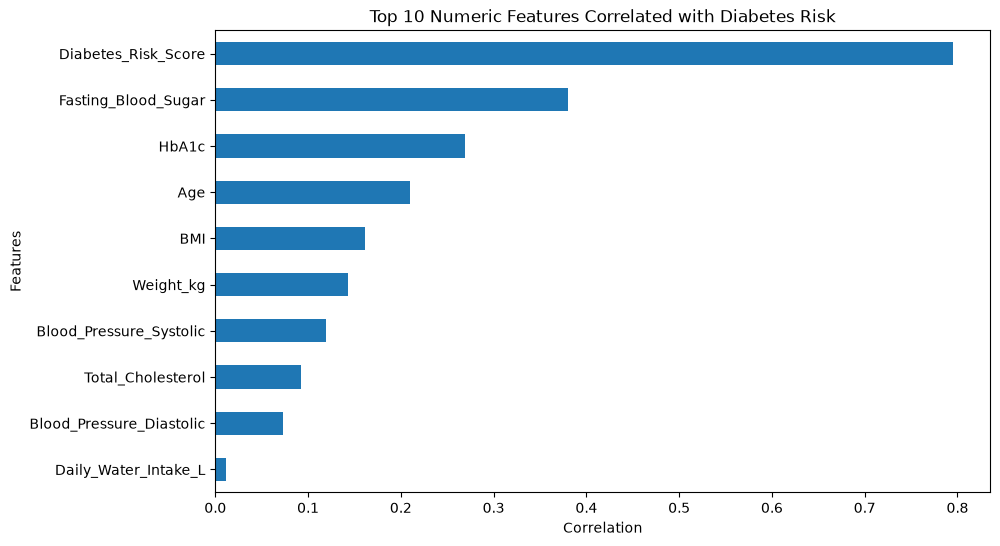

In [167]:
risk_corr = (
    df.select_dtypes(include="number")
      .corr()["Diabetes_Risk_Num"]
      .drop("Diabetes_Risk_Num")
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

risk_corr.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Numeric Features Correlated with Diabetes Risk")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [168]:
activity_risk = pd.crosstab(
    df["Physical_Activity_Level"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(activity_risk.round(2))

Diabetes_Risk             High   Low  Moderate
Physical_Activity_Level                       
High                     68.99  1.34     29.68
Low                      80.49  0.40     19.11
Moderate                 69.73  1.10     29.16


In [169]:
medication_risk = pd.crosstab(
    df["Medication_Adherence"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(medication_risk.round(2))

Diabetes_Risk          High   Low  Moderate
Medication_Adherence                       
Average               70.70  1.18     28.12
Good                  70.81  1.05     28.14
Poor                  78.21  0.58     21.21


In [170]:
smoking_risk = pd.crosstab(
    df["Smoking_Status"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(smoking_risk.round(2))

Diabetes_Risk    High   Low  Moderate
Smoking_Status                       
Current         79.65  0.53     19.82
Former          69.96  1.11     28.93
Never           69.93  1.18     28.89


In [171]:
diet_risk = pd.crosstab(
    df["Diet_Quality"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(diet_risk.round(2))

Diabetes_Risk   High   Low  Moderate
Diet_Quality                        
Average        69.68  1.16     29.16
Healthy        69.30  1.30     29.39
Poor           80.70  0.35     18.95


In [172]:
stress_risk = pd.crosstab(
    df["Stress_Level"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(stress_risk.round(2))

Diabetes_Risk   High   Low  Moderate
Stress_Level                        
High           79.38  0.47     20.15
Low            69.45  1.27     29.28
Moderate       70.73  1.07     28.20


In [173]:
family_risk = pd.crosstab(
    df["Family_History_Diabetes"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(family_risk.round(2))

Diabetes_Risk             High   Low  Moderate
Family_History_Diabetes                       
No                       63.52  1.57     34.91
Yes                      82.91  0.31     16.78


In [174]:
alcohol_risk = pd.crosstab(
    df["Alcohol_Consumption"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(alcohol_risk.round(2))

Diabetes_Risk         High   Low  Moderate
Alcohol_Consumption                       
Frequently           78.15  0.60     21.25
Never                70.24  1.17     28.60
Occasionally         71.20  1.05     27.75


In [175]:
sugar_risk = pd.crosstab(
    df["Sugar_Intake_Level"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(sugar_risk.round(2))

Diabetes_Risk        High   Low  Moderate
Sugar_Intake_Level                       
High                73.46  0.97     25.57
Low                 73.12  0.91     25.97
Moderate            72.98  0.94     26.07


In [176]:
fatty_liver_risk = pd.crosstab(
    df["Fatty_Liver"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(fatty_liver_risk.round(2))

Diabetes_Risk   High   Low  Moderate
Fatty_Liver                         
No             69.48  1.30     29.22
Yes            76.94  0.57     22.49


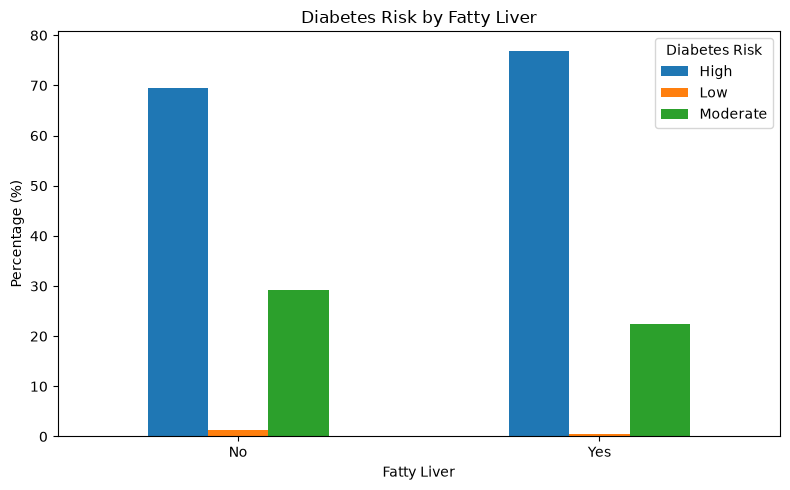

In [177]:
import matplotlib.pyplot as plt

fatty_liver_risk = pd.crosstab(
    df["Fatty_Liver"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

ax = fatty_liver_risk.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Diabetes Risk by Fatty Liver")
plt.xlabel("Fatty Liver")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Diabetes Risk")
plt.tight_layout()

plt.savefig("fatty_liver_risk.svg", format="svg")
plt.show()

In [178]:
pcos_risk = pd.crosstab(
    df["PCOS"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(pcos_risk.round(2))

Diabetes_Risk   High   Low  Moderate
PCOS                                
No             68.11  1.34     30.55
Yes            78.29  0.53     21.17


In [179]:
work_risk = pd.crosstab(
    df["Work_Type"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(work_risk.round(2))

Diabetes_Risk   High   Low  Moderate
Work_Type                           
Business       72.75  1.17     26.08
Government     73.52  0.78     25.70
Private        73.46  0.99     25.55
Retired        72.85  0.90     26.26
Student        73.36  0.85     25.78


In [180]:
residence_risk = pd.crosstab(
    df["Residence_Type"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(residence_risk.round(2))

Diabetes_Risk    High   Low  Moderate
Residence_Type                       
Rural           73.46  0.87     25.67
Urban           72.92  1.01     26.07


In [181]:
doctor_risk = pd.crosstab(
    df["Doctor_Consultation_Needed"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(doctor_risk.round(2))

Diabetes_Risk                High    Low  Moderate
Doctor_Consultation_Needed                        
No                           0.00  11.67     88.33
Yes                         78.82   0.11     21.07


In [182]:
country_risk = pd.crosstab(
    df["Country"],
    df["Diabetes_Risk"],
    normalize="index"
) * 100

print(country_risk.round(2))

Diabetes_Risk    High   Low  Moderate
Country                              
Argentina       73.46  0.77     25.77
Australia       72.65  1.02     26.33
Bangladesh      72.23  0.71     27.06
Brazil          72.60  1.17     26.23
Canada          72.24  0.68     27.07
China           72.59  0.73     26.68
Egypt           74.18  0.75     25.07
France          74.42  1.26     24.32
Germany         72.74  1.20     26.06
India           74.42  0.86     24.72
Indonesia       73.89  1.14     24.96
Italy           72.65  0.80     26.55
Japan           71.96  1.06     26.98
Malaysia        73.98  1.15     24.87
Mexico          71.39  0.95     27.66
Nigeria         73.60  1.04     25.36
Pakistan        74.63  1.07     24.30
Russia          72.82  0.82     26.36
Saudi Arabia    73.84  0.95     25.21
South Africa    72.80  1.00     26.20
South Korea     71.41  1.00     27.59
Spain           73.54  0.65     25.81
Turkey          75.10  0.76     24.14
United Kingdom  73.64  1.03     25.33
United State

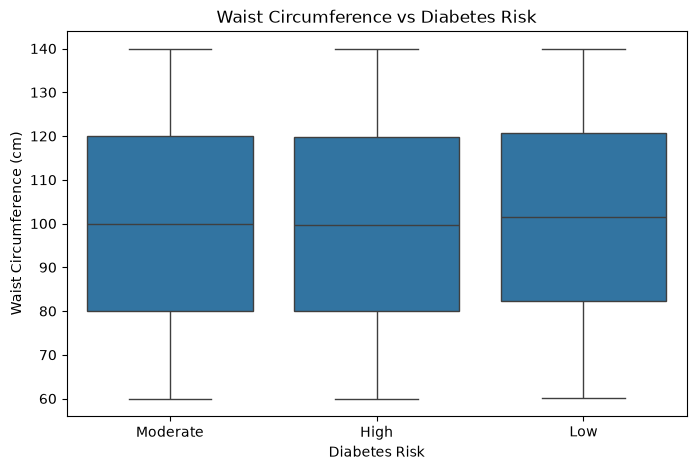

In [183]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Diabetes_Risk",
    y="Waist_Circumference_cm",
    data=df
)

plt.title("Waist Circumference vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Waist Circumference (cm)")
plt.show()

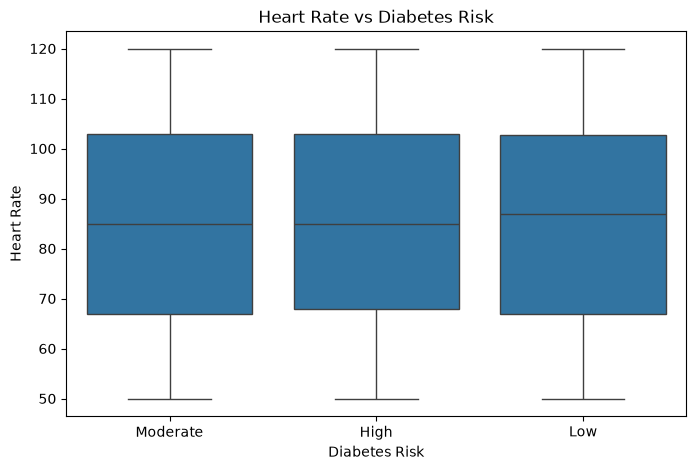

In [184]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Diabetes_Risk",
    y="Heart_Rate",
    data=df
)

plt.title("Heart Rate vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Heart Rate")
plt.show()

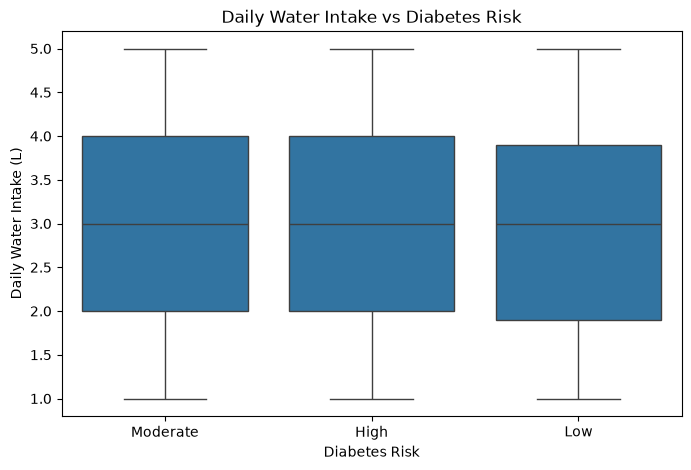

In [185]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Diabetes_Risk",
    y="Daily_Water_Intake_L",
    data=df
)

plt.title("Daily Water Intake vs Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Daily Water Intake (L)")
plt.show()

In [186]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Family_History_Diabetes"],
    df["Diabetes_Risk"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Significant Association")
else:
    print("No Significant Association")

Chi-Square Statistic: 2439.772432852407
P-value: 0.0
Significant Association


In [187]:
import pandas as pd
from scipy.stats import chi2_contingency

categorical_columns = [
    "Gender",
    "Country",
    "Physical_Activity_Level",
    "Diet_Quality",
    "Sugar_Intake_Level",
    "Stress_Level",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Family_History_Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Fatty_Liver",
    "PCOS",
    "Medication_Adherence",
    "Work_Type",
    "Residence_Type",
    "Doctor_Consultation_Needed"
]

results = []

for col in categorical_columns:

    table = pd.crosstab(
        df[col],
        df["Diabetes_Risk"]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "Variable": col,
        "Chi2": chi2,
        "P_Value": p,
        "Significant": "Yes" if p < 0.05 else "No"
    })

chi_square_results = pd.DataFrame(results)

chi_square_results = chi_square_results.sort_values(
    by="Chi2",
    ascending=False
)

print(chi_square_results.round(4))

                      Variable        Chi2  P_Value Significant
16  Doctor_Consultation_Needed  13332.7968   0.0000         Yes
8      Family_History_Diabetes   2439.7724   0.0000         Yes
9                 Hypertension    949.1383   0.0000         Yes
2      Physical_Activity_Level    742.0928   0.0000         Yes
3                 Diet_Quality    739.1859   0.0000         Yes
12                        PCOS    689.4580   0.0000         Yes
10               Heart_Disease    658.3799   0.0000         Yes
6               Smoking_Status    543.0829   0.0000         Yes
5                 Stress_Level    515.5940   0.0000         Yes
11                 Fatty_Liver    385.3663   0.0000         Yes
7          Alcohol_Consumption    324.4315   0.0000         Yes
13        Medication_Adherence    321.0970   0.0000         Yes
1                      Country     41.9870   0.7165          No
14                   Work_Type     11.7358   0.1634          No
0                       Gender      4.55

In [188]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

categorical_columns = [
    "Gender",
    "Country",
    "Physical_Activity_Level",
    "Diet_Quality",
    "Sugar_Intake_Level",
    "Stress_Level",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Family_History_Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Fatty_Liver",
    "PCOS",
    "Medication_Adherence",
    "Work_Type",
    "Residence_Type",
    "Doctor_Consultation_Needed"
]

results = []

for col in categorical_columns:

    table = pd.crosstab(
        df[col],
        df["Diabetes_Risk"]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    rows, cols = table.shape

    phi2 = chi2 / n

    cramers_v = np.sqrt(
        phi2 / min(cols - 1, rows - 1)
    )

    results.append({
        "Variable": col,
        "Chi2": chi2,
        "P_Value": p,
        "Cramers_V": cramers_v
    })

cramers_results = pd.DataFrame(results)

cramers_results = cramers_results.sort_values(
    by="Cramers_V",
    ascending=False
)

print(cramers_results.round(4))

                      Variable        Chi2  P_Value  Cramers_V
16  Doctor_Consultation_Needed  13332.7968   0.0000     0.5164
8      Family_History_Diabetes   2439.7724   0.0000     0.2209
9                 Hypertension    949.1383   0.0000     0.1378
12                        PCOS    689.4580   0.0000     0.1174
10               Heart_Disease    658.3799   0.0000     0.1148
11                 Fatty_Liver    385.3663   0.0000     0.0878
2      Physical_Activity_Level    742.0928   0.0000     0.0861
3                 Diet_Quality    739.1859   0.0000     0.0860
6               Smoking_Status    543.0829   0.0000     0.0737
5                 Stress_Level    515.5940   0.0000     0.0718
7          Alcohol_Consumption    324.4315   0.0000     0.0570
13        Medication_Adherence    321.0970   0.0000     0.0567
1                      Country     41.9870   0.7165     0.0205
14                   Work_Type     11.7358   0.1634     0.0108
15              Residence_Type      3.9737   0.1371    

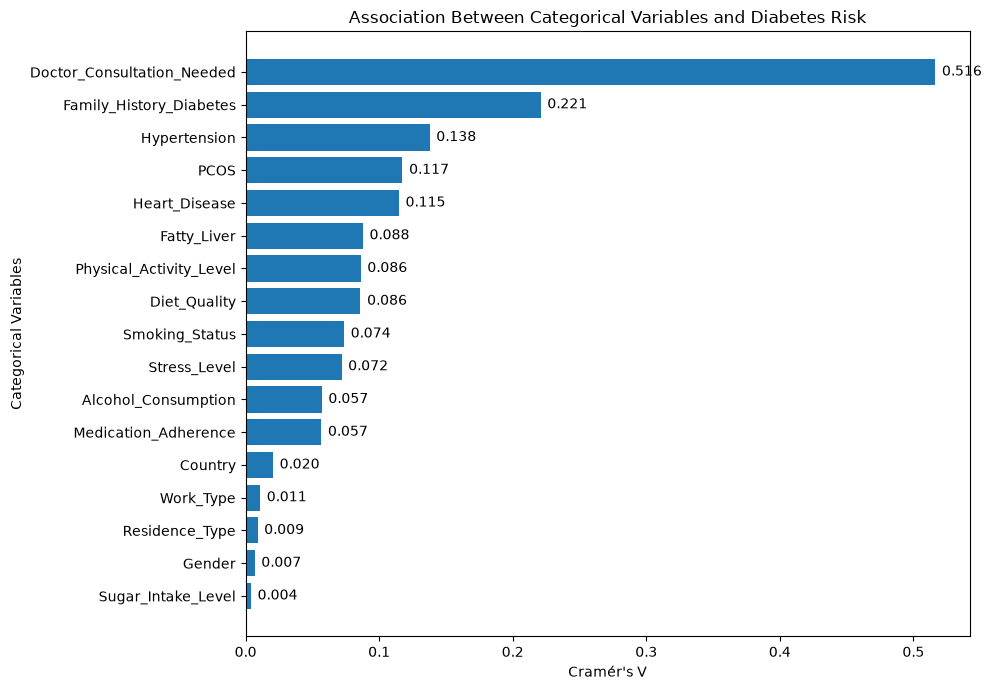

In [189]:
import matplotlib.pyplot as plt

# Cramer's V ko ascending order me sort karna
plot_data = cramers_results.sort_values(by="Cramers_V")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Variable"],
    plot_data["Cramers_V"]
)

plt.xlabel("Cramér's V")
plt.ylabel("Categorical Variables")
plt.title("Association Between Categorical Variables and Diabetes Risk")

# Values bars ke end par show karna
for i, value in enumerate(plot_data["Cramers_V"]):
    plt.text(
        value + 0.005,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

# SVG file save
plt.savefig("cramers_v_diabetes_risk.svg", format="svg")

plt.show()

In [190]:
import pandas as pd
from scipy.stats import f_oneway

# Numerical columns
numerical_columns = [
    "Age",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Waist_Circumference_cm",
    "Blood_Glucose",
    "HbA1c",
    "Fasting_Blood_Sugar",
    "Insulin_Level",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Total_Cholesterol",
    "HDL",
    "LDL",
    "Triglycerides",
    "Heart_Rate",
    "Exercise_Hours_Per_Week",
    "Daily_Walking_Minutes",
    "Sleep_Hours",
    "Daily_Water_Intake_L",
    "Diabetes_Risk_Score"
]

results = []

for col in numerical_columns:

    # Har risk group ka data
    high = df.loc[df["Diabetes_Risk"] == "High", col]
    moderate = df.loc[df["Diabetes_Risk"] == "Moderate", col]
    low = df.loc[df["Diabetes_Risk"] == "Low", col]

    # One-way ANOVA
    f_stat, p_value = f_oneway(high, moderate, low)

    results.append({
        "Variable": col,
        "F_Statistic": f_stat,
        "P_Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

# Results DataFrame
anova_results = pd.DataFrame(results)

# P-value ke according sort
anova_results = anova_results.sort_values(
    by="P_Value",
    ascending=True
)

print(anova_results.round(6))

                    Variable   F_Statistic   P_Value Significant
0                        Age   1152.207946  0.000000         Yes
7        Fasting_Blood_Sugar   4231.431224  0.000000         Yes
6                      HbA1c   1966.357015  0.000000         Yes
20       Diabetes_Risk_Score  43112.910731  0.000000         Yes
3                        BMI    670.040112  0.000000         Yes
2                  Weight_kg    521.765411  0.000000         Yes
9    Blood_Pressure_Systolic    364.481071  0.000000         Yes
11         Total_Cholesterol    216.329783  0.000000         Yes
1                  Height_cm    140.100167  0.000000         Yes
10  Blood_Pressure_Diastolic    132.208547  0.000000         Yes
18               Sleep_Hours     60.801695  0.000000         Yes
19      Daily_Water_Intake_L      3.252427  0.038688         Yes
12                       HDL      1.401466  0.246245          No
8              Insulin_Level      1.203019  0.300295          No
5              Blood_Gluc

In [191]:
import pandas as pd
from scipy.stats import f_oneway

numerical_columns = [
    "Age",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Waist_Circumference_cm",
    "Blood_Glucose",
    "HbA1c",
    "Fasting_Blood_Sugar",
    "Insulin_Level",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Total_Cholesterol",
    "HDL",
    "LDL",
    "Triglycerides",
    "Heart_Rate",
    "Exercise_Hours_Per_Week",
    "Daily_Walking_Minutes",
    "Sleep_Hours",
    "Daily_Water_Intake_L",
    "Diabetes_Risk_Score"
]

results = []

for col in numerical_columns:

    high = df.loc[df["Diabetes_Risk"] == "High", col]
    moderate = df.loc[df["Diabetes_Risk"] == "Moderate", col]
    low = df.loc[df["Diabetes_Risk"] == "Low", col]

    # ANOVA
    f_stat, p_value = f_oneway(high, moderate, low)

    # Grand Mean
    grand_mean = df[col].mean()

    # Between-group Sum of Squares
    ss_between = (
        len(high) * (high.mean() - grand_mean) ** 2 +
        len(moderate) * (moderate.mean() - grand_mean) ** 2 +
        len(low) * (low.mean() - grand_mean) ** 2
    )

    # Total Sum of Squares
    ss_total = ((df[col] - grand_mean) ** 2).sum()

    # Eta Squared
    eta_squared = ss_between / ss_total

    results.append({
        "Variable": col,
        "F_Statistic": f_stat,
        "P_Value": p_value,
        "Eta_Squared": eta_squared
    })

eta_results = pd.DataFrame(results)

# Strongest effect first
eta_results = eta_results.sort_values(
    by="Eta_Squared",
    ascending=False
)

print(eta_results.round(4))

                    Variable  F_Statistic  P_Value  Eta_Squared
20       Diabetes_Risk_Score   43112.9107   0.0000       0.6330
7        Fasting_Blood_Sugar    4231.4312   0.0000       0.1448
6                      HbA1c    1966.3570   0.0000       0.0729
0                        Age    1152.2079   0.0000       0.0441
3                        BMI     670.0401   0.0000       0.0261
2                  Weight_kg     521.7654   0.0000       0.0204
9    Blood_Pressure_Systolic     364.4811   0.0000       0.0144
11         Total_Cholesterol     216.3298   0.0000       0.0086
1                  Height_cm     140.1002   0.0000       0.0056
10  Blood_Pressure_Diastolic     132.2085   0.0000       0.0053
18               Sleep_Hours      60.8017   0.0000       0.0024
19      Daily_Water_Intake_L       3.2524   0.0387       0.0001
12                       HDL       1.4015   0.2462       0.0001
8              Insulin_Level       1.2030   0.3003       0.0000
5              Blood_Glucose       0.720

In [192]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# ANOVA me significant variables
significant_variables = [
    "Age",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "HbA1c",
    "Fasting_Blood_Sugar",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Total_Cholesterol",
    "Sleep_Hours",
    "Daily_Water_Intake_L",
    "Diabetes_Risk_Score"
]

# Har variable ke liye Tukey HSD
for col in significant_variables:

    print("\n" + "=" * 70)
    print(f"Tukey HSD Test: {col}")
    print("=" * 70)

    tukey = pairwise_tukeyhsd(
        endog=df[col],
        groups=df["Diabetes_Risk"],
        alpha=0.05
    )

    print(tukey)


Tukey HSD Test: Age
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj  lower    upper   reject
-------------------------------------------------------
  High      Low -17.5607   0.0 -19.7973 -15.3241   True
  High Moderate    -9.53   0.0 -10.0228  -9.0372   True
   Low Moderate   8.0307   0.0   5.7683  10.2931   True
-------------------------------------------------------

Tukey HSD Test: Height_cm
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj   lower   upper  reject
------------------------------------------------------
  High      Low   4.0829    0.0  2.5611  5.6047   True
  High Moderate   2.2675    0.0  1.9322  2.6028   True
   Low Moderate  -1.8154 0.0158 -3.3547 -0.2761   True
------------------------------------------------------

Tukey HSD Test: Weight_kg
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2  meandiff p-adj  lower    upper   reject
------------------------------------

In [193]:
leakage_columns = [
    "Diabetes_Risk_Score",
    "Doctor_Consultation_Needed"
]

for col in leakage_columns:
    print("\n", col)
    print(df.groupby("Diabetes_Risk")[col].value_counts(normalize=True).round(4))


 Diabetes_Risk_Score
Diabetes_Risk  Diabetes_Risk_Score
High           100                    0.0679
               76                     0.0346
               75                     0.0338
               78                     0.0337
               72                     0.0333
                                       ...  
Moderate       39                     0.0102
               38                     0.0077
               36                     0.0076
               37                     0.0073
               35                     0.0066
Name: proportion, Length: 86, dtype: float64

 Doctor_Consultation_Needed
Diabetes_Risk  Doctor_Consultation_Needed
High           Yes                           1.0000
Low            No                            0.8872
               Yes                           0.1128
Moderate       Yes                           0.7560
               No                            0.2440
Name: proportion, dtype: float64


In [194]:
features = [
    "Age",
    "Gender",
    "Country",
    "Height_cm",
    "Weight_kg",
    "BMI",
    "Waist_Circumference_cm",
    "Blood_Glucose",
    "HbA1c",
    "Fasting_Blood_Sugar",
    "Insulin_Level",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Total_Cholesterol",
    "HDL",
    "LDL",
    "Triglycerides",
    "Heart_Rate",
    "Physical_Activity_Level",
    "Exercise_Hours_Per_Week",
    "Daily_Walking_Minutes",
    "Diet_Quality",
    "Sugar_Intake_Level",
    "Sleep_Hours",
    "Stress_Level",
    "Smoking_Status",
    "Alcohol_Consumption",
    "Family_History_Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Fatty_Liver",
    "PCOS",
    "Medication_Adherence",ok
    "Work_Type",
    "Residence_Type",
    "Daily_Water_Intake_L"
]

target = "Diabetes_Risk"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 36)
y shape: (50000,)


In [196]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

X_mi = X.copy()

# Categorical columns
categorical_cols = X_mi.select_dtypes(include="str").columns

# Encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col].astype(str))

# Target encode
y_mi = LabelEncoder().fit_transform(y)

# Mutual Information
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

# Create result DataFrame
mi_results = pd.DataFrame({
    "Feature": X_mi.columns,
    "MI_Score": mi_scores
})

# Highest MI first
mi_results = mi_results.sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)

print(mi_results.round(4))

                     Feature  MI_Score
0        Fasting_Blood_Sugar    0.0984
1                      HbA1c    0.0568
2    Family_History_Diabetes    0.0310
3                        Age    0.0243
4               Hypertension    0.0174
5                        BMI    0.0145
6              Heart_Disease    0.0145
7    Physical_Activity_Level    0.0130
8                       PCOS    0.0122
9                  Weight_kg    0.0108
10   Blood_Pressure_Systolic    0.0106
11               Fatty_Liver    0.0097
12              Diet_Quality    0.0089
13              Stress_Level    0.0085
14            Smoking_Status    0.0074
15            Residence_Type    0.0060
16      Medication_Adherence    0.0059
17       Alcohol_Consumption    0.0052
18         Total_Cholesterol    0.0047
19             Blood_Glucose    0.0038
20        Sugar_Intake_Level    0.0032
21                 Height_cm    0.0022
22                    Gender    0.0012
23               Sleep_Hours    0.0010
24     Daily_Walking_Minu

In [197]:
# Mutual Information results
mi_results.head(15)

,Feature,MI_Score
0,Fasting_Blood_Sugar,0.098379
1,HbA1c,0.056767
2,Family_History_Diabetes,0.031016
3,Age,0.024261
4,Hypertension,0.017398
5,BMI,0.014521
6,Heart_Disease,0.014464
7,Physical_Activity_Level,0.013048
8,PCOS,0.012154
9,Weight_kg,0.010814


In [198]:
# Top 15 MI features
top_15_mi = mi_results.head(15)

print(top_15_mi.to_string(index=False))

                Feature  MI_Score
    Fasting_Blood_Sugar  0.098379
                  HbA1c  0.056767
Family_History_Diabetes  0.031016
                    Age  0.024261
           Hypertension  0.017398
                    BMI  0.014521
          Heart_Disease  0.014464
Physical_Activity_Level  0.013048
                   PCOS  0.012154
              Weight_kg  0.010814
Blood_Pressure_Systolic  0.010552
            Fatty_Liver  0.009740
           Diet_Quality  0.008868
           Stress_Level  0.008546
         Smoking_Status  0.007351


In [199]:
# -------------------------------
# 1. MI results
# -------------------------------

mi_df = mi_results[["Feature", "MI_Score"]].copy()


# -------------------------------
# 2. Eta Squared results
# -------------------------------

eta_df = eta_results[["Variable", "Eta_Squared"]].copy()

eta_df = eta_df.rename(
    columns={"Variable": "Feature"}
)


# -------------------------------
# 3. Cramer's V results
# -------------------------------

cramer_df = cramers_results[["Variable", "Cramers_V"]].copy()

cramer_df = cramer_df.rename(
    columns={"Variable": "Feature"}
)


# -------------------------------
# 4. Correlation with target
# -------------------------------

correlation_df = (
    df.corr(numeric_only=True)["Diabetes_Risk_Num"]
    .drop("Diabetes_Risk_Num")
    .abs()
    .reset_index()
)

correlation_df.columns = ["Feature", "Correlation"]


# -------------------------------
# 5. Combine all results
# -------------------------------

feature_analysis = mi_df.merge(
    eta_df,
    on="Feature",
    how="outer"
)

feature_analysis = feature_analysis.merge(
    cramer_df,
    on="Feature",
    how="outer"
)

feature_analysis = feature_analysis.merge(
    correlation_df,
    on="Feature",
    how="outer"
)


# -------------------------------
# 6. Fill missing values
# -------------------------------

feature_analysis = feature_analysis.fillna(0)


# -------------------------------
# 7. Sort by MI
# -------------------------------

feature_analysis = feature_analysis.sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)


print(feature_analysis.round(4).to_string(index=False))

                   Feature  MI_Score  Eta_Squared  Cramers_V  Correlation
       Fasting_Blood_Sugar    0.0984       0.1448     0.0000       0.3800
                     HbA1c    0.0568       0.0729     0.0000       0.2692
   Family_History_Diabetes    0.0310       0.0000     0.2209       0.0000
                       Age    0.0243       0.0441     0.0000       0.2098
              Hypertension    0.0174       0.0000     0.1378       0.0000
                       BMI    0.0145       0.0261     0.0000       0.1614
             Heart_Disease    0.0145       0.0000     0.1148       0.0000
   Physical_Activity_Level    0.0130       0.0000     0.0861       0.0000
                      PCOS    0.0122       0.0000     0.1174       0.0000
                 Weight_kg    0.0108       0.0204     0.0000       0.1428
   Blood_Pressure_Systolic    0.0106       0.0144     0.0000       0.1199
               Fatty_Liver    0.0097       0.0000     0.0878       0.0000
              Diet_Quality    0.0089  

In [200]:
selected_features = [
    "Fasting_Blood_Sugar",
    "HbA1c",
    "Family_History_Diabetes",
    "Age",
    "Hypertension",
    "BMI",
    "Heart_Disease",
    "Physical_Activity_Level",
    "PCOS",
    "Weight_kg",
    "Blood_Pressure_Systolic",
    "Fatty_Liver",
    "Diet_Quality",
    "Stress_Level",
    "Smoking_Status"
]

X_selected = df[selected_features]
y = df["Diabetes_Risk"]

print("Selected features:", len(selected_features))
print("X_selected shape:", X_selected.shape)
print("y shape:", y.shape)

Selected features: 15
X_selected shape: (50000, 15)
y shape: (50000,)


In [201]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 15)
X_test shape: (10000, 15)
y_train shape: (40000,)
y_test shape: (10000,)


In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical columns
categorical_cols = [
    "Family_History_Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Physical_Activity_Level",
    "PCOS",
    "Fatty_Liver",
    "Diet_Quality",
    "Stress_Level",
    "Smoking_Status"
]

# Numerical columns
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Physical_Activity_Level', 'PCOS', 'Fatty_Liver', 'Diet_Quality', 'Stress_Level', 'Smoking_Status']

Numerical columns:
['Fasting_Blood_Sugar', 'HbA1c', 'Age', 'BMI', 'Weight_kg', 'Blood_Pressure_Systolic']


In [203]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numerical_cols
        )
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (40000, 28)
X_test_encoded shape: (10000, 28)


In [204]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index
)

print(X_train_encoded_df.head())
print("\nShape:", X_train_encoded_df.shape)

       cat__Family_History_Diabetes_No  cat__Family_History_Diabetes_Yes  \
32943                              1.0                               0.0   
48323                              1.0                               0.0   
37019                              1.0                               0.0   
45232                              0.0                               1.0   
48854                              1.0                               0.0   

       cat__Hypertension_No  cat__Hypertension_Yes  cat__Heart_Disease_No  \
32943                   1.0                    0.0                    0.0   
48323                   0.0                    1.0                    0.0   
37019                   0.0                    1.0                    1.0   
45232                   1.0                    0.0                    0.0   
48854                   1.0                    0.0                    1.0   

       cat__Heart_Disease_Yes  cat__Physical_Activity_Level_High  \
32943       

In [206]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_encoded_df[num_encoded_cols] = scaler.fit_transform(
    X_train_encoded_df[num_encoded_cols]
)

X_test_encoded_df[num_encoded_cols] = scaler.transform(
    X_test_encoded_df[num_encoded_cols]
)

print("Scaling completed.")
print(X_train_encoded_df.shape)
print(X_test_encoded_df.shape)

Scaling completed.
(40000, 28)
(10000, 28)


In [205]:
num_encoded_cols = [
    col for col in X_train_encoded_df.columns
    if col.startswith("num__")
]

print(num_encoded_cols)

['num__Fasting_Blood_Sugar', 'num__HbA1c', 'num__Age', 'num__BMI', 'num__Weight_kg', 'num__Blood_Pressure_Systolic']


In [207]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True).mul(100).round(2)
)

Training target distribution:
Diabetes_Risk
High        29274
Moderate    10350
Low           376
Name: count, dtype: int64

Training target percentage:
Diabetes_Risk
High        73.18
Moderate    25.87
Low          0.94
Name: proportion, dtype: float64


In [208]:
print("Test target distribution:")
print(y_test.value_counts())

print("\nTest target percentage:")
print(
    y_test.value_counts(normalize=True).mul(100).round(2)
)

Test target distribution:
Diabetes_Risk
High        7319
Moderate    2587
Low           94
Name: count, dtype: int64

Test target percentage:
Diabetes_Risk
High        73.19
Moderate    25.87
Low          0.94
Name: proportion, dtype: float64


In [209]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train
log_reg.fit(
    X_train_encoded_df,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [210]:
y_pred = log_reg.predict(X_test_encoded_df)

print("Predictions completed.")
print(y_pred[:20])

Predictions completed.
['Moderate' 'Low' 'High' 'High' 'High' 'Low' 'High' 'Moderate' 'High'
 'Low' 'Moderate' 'High' 'High' 'High' 'Moderate' 'High' 'High' 'High'
 'High' 'Moderate']


In [212]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4)*100,"%")

Accuracy: 81.37 %


Confusion Matrix:
[[  85    9    0]
 [ 329 1905  353]
 [   2 1170 6147]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.20      0.90      0.33        94
    Moderate       0.62      0.74      0.67      2587
        High       0.95      0.84      0.89      7319

    accuracy                           0.81     10000
   macro avg       0.59      0.83      0.63     10000
weighted avg       0.85      0.81      0.83     10000



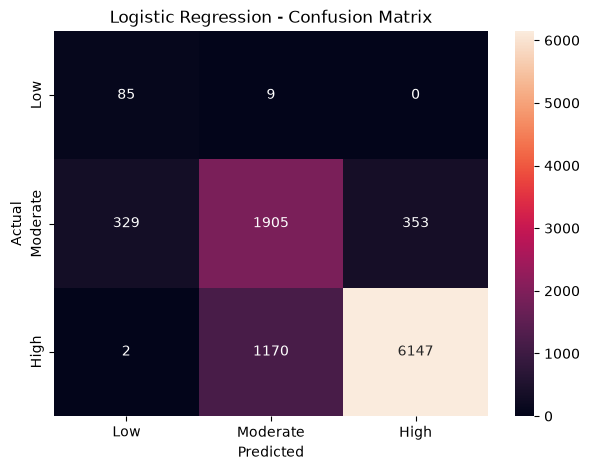

In [213]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Moderate", "High"]
)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    )
)

# Heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Moderate", "High"],
    yticklabels=["Low", "Moderate", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Random Forest training completed.

Predictions completed.
['Moderate' 'Moderate' 'High' 'High' 'High' 'Moderate' 'High' 'High'
 'High' 'Moderate' 'High' 'High' 'Moderate' 'High' 'Moderate' 'High'
 'High' 'High' 'High' 'Moderate']

Random Forest Accuracy: 89.55 %

Confusion Matrix:
[[  22   72    0]
 [   6 2278  303]
 [   0  664 6655]]


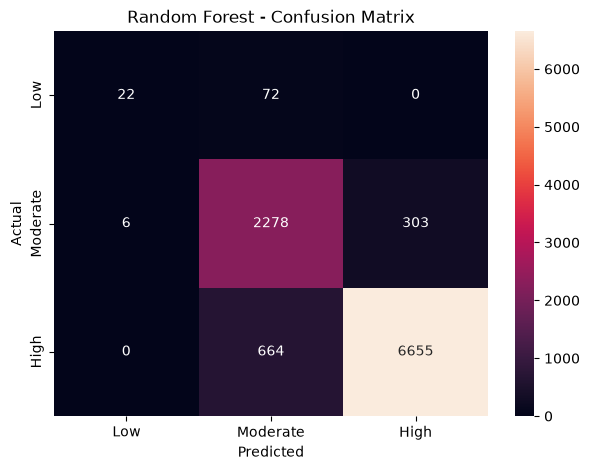


Classification Report:
              precision    recall  f1-score   support

         Low       0.79      0.23      0.36        94
    Moderate       0.76      0.88      0.81      2587
        High       0.96      0.91      0.93      7319

    accuracy                           0.90     10000
   macro avg       0.83      0.67      0.70     10000
weighted avg       0.90      0.90      0.90     10000



In [214]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Training
rf_model.fit(X_train_encoded_df, y_train)

print("Random Forest training completed.")

# Prediction
y_pred_rf = rf_model.predict(X_test_encoded_df)

print("\nPredictions completed.")
print(y_pred_rf[:20])

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

# Confusion Matrix
labels = ["Low", "Moderate", "High"]

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=labels
)

print("\nConfusion Matrix:")
print(cm_rf)

# Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=labels,
        zero_division=0
    )
)

Before SMOTE:
Diabetes_Risk
High        29274
Moderate    10350
Low           376
Name: count, dtype: int64

After SMOTE:
Diabetes_Risk
High        29274
Moderate    29274
Low         29274
Name: count, dtype: int64

Random Forest + SMOTE training completed.

Random Forest + SMOTE Accuracy: 89.98 %

Confusion Matrix:
[[  36   58    0]
 [  13 2136  438]
 [   0  493 6826]]


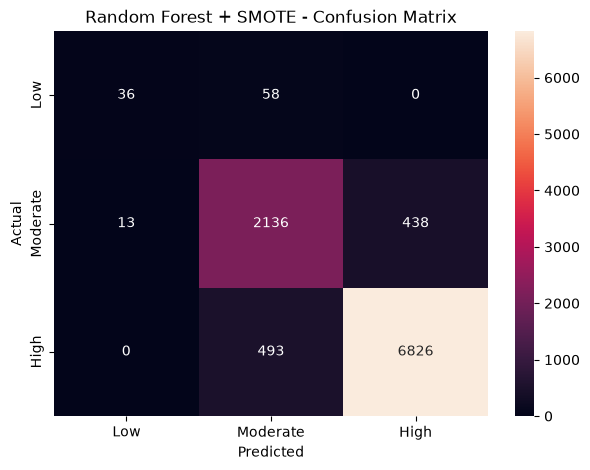


Classification Report:
              precision    recall  f1-score   support

         Low       0.73      0.38      0.50        94
    Moderate       0.79      0.83      0.81      2587
        High       0.94      0.93      0.94      7319

    accuracy                           0.90     10000
   macro avg       0.82      0.71      0.75     10000
weighted avg       0.90      0.90      0.90     10000



In [216]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded_df,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


# Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Training
rf_smote.fit(
    X_train_smote,
    y_train_smote
)

print("\nRandom Forest + SMOTE training completed.")


# Prediction
y_pred_smote = rf_smote.predict(
    X_test_encoded_df
)

# Accuracy
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

print("\nRandom Forest + SMOTE Accuracy:",
      round(accuracy_smote * 100, 2), "%")


# Confusion Matrix
labels = ["Low", "Moderate", "High"]

cm_smote = confusion_matrix(
    y_test,
    y_pred_smote,
    labels=labels
)

print("\nConfusion Matrix:")
print(cm_smote)


# Heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest + SMOTE - Confusion Matrix")
plt.show()


# Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_smote,
        labels=labels,
        zero_division=0
    )
)

Random Forest + SMOTE training completed.

Predictions completed.

Random Forest + SMOTE Accuracy: 89.98 %

Confusion Matrix:
[[  36   58    0]
 [  13 2136  438]
 [   0  493 6826]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.73      0.38      0.50        94
    Moderate       0.79      0.83      0.81      2587
        High       0.94      0.93      0.94      7319

    accuracy                           0.90     10000
   macro avg       0.82      0.71      0.75     10000
weighted avg       0.90      0.90      0.90     10000



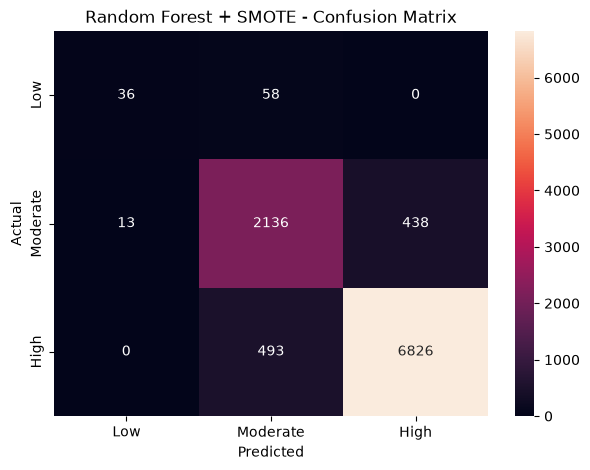

In [217]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest + SMOTE
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Training
rf_smote.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest + SMOTE training completed.")


# Prediction
y_pred_smote = rf_smote.predict(X_test_encoded_df)

print("\nPredictions completed.")


# Accuracy
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

print("\nRandom Forest + SMOTE Accuracy:",
      round(accuracy_smote * 100, 2), "%")


# Confusion Matrix
labels = ["Low", "Moderate", "High"]

cm_smote = confusion_matrix(
    y_test,
    y_pred_smote,
    labels=labels
)

print("\nConfusion Matrix:")
print(cm_smote)


# Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_smote,
        labels=labels,
        zero_division=0
    )
)


# Heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest + SMOTE - Confusion Matrix")

plt.show()